In [1]:
from qubic.lib.Qhdf5 import HDF5Dict
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from qubic.lib.QskySim import get_angular_profile

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [2]:
hdf5 = HDF5Dict()
data = hdf5.load_dict("parametric_d0_DB_test_convo_out/Dict/test_None.h5")
print(data["fwhm_rec"])

0.0042841330748209575


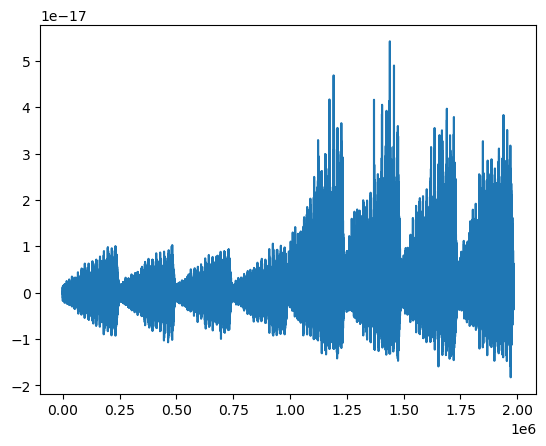

In [3]:
plt.plot(data["TOD_qubic"])

In [4]:
data.keys()

dict_keys(['convergence', 'fsky', 'fwhm_rec', 'index_beta', 'A', 'Atrue', 'G', 'TOD_external', 'TOD_qubic', 'all_gain', 'beta', 'beta_true', 'center', 'comps_name', 'coverage', 'fwhm_in', 'fwhm_out', 'g', 'gi', 'maps', 'maps_in', 'maps_in_convolved', 'maps_noise', 'nus_in', 'nus_out', 'parameters', 'qubic_dict', 'seenpix'])

In [5]:
data["TOD_external"].shape

(1179648,)

In [6]:
fwhm_in = data["fwhm_in"]
fwhm_out = data["fwhm_out"]
fwhm_rec = data["fwhm_rec"]
seenpix = data["seenpix"]

comp_maps_input = data["maps_in_convolved"]
comp_maps_input = comp_maps_input
comp_maps_rec = data["maps"]
comp_maps_res = comp_maps_input - comp_maps_rec
comp_maps_input[:, ~seenpix] = hp.UNSEEN
comp_maps_rec[:,  ~seenpix] = hp.UNSEEN
comp_maps_res[:, ~seenpix] = hp.UNSEEN

# for i in range(comp_maps_input.shape[0]):
#     C = HealpixConvolutionGaussianOperator(np.max(fwhm_in))
#     comp_maps_input[i] = C(comp_maps_input[i])
#     comp_maps_rec[i] = C(comp_maps_rec[i])

comp_maps_res = comp_maps_input - comp_maps_rec
center = data["center"]
seenpix = data["seenpix"]
convergence = data["convergence"]
print(comp_maps_input.shape)

(2, 196608, 3)


/tmp/ipykernel_1294348/1305229284.py:9: RuntimeWarning: invalid value encountered in divide
  test_ratio_cmb = test_input_cmb / test_rec_cmb
/tmp/ipykernel_1294348/1305229284.py:10: RuntimeWarning: invalid value encountered in divide
  test_ratio_dust = test_input_dust / test_rec_dust


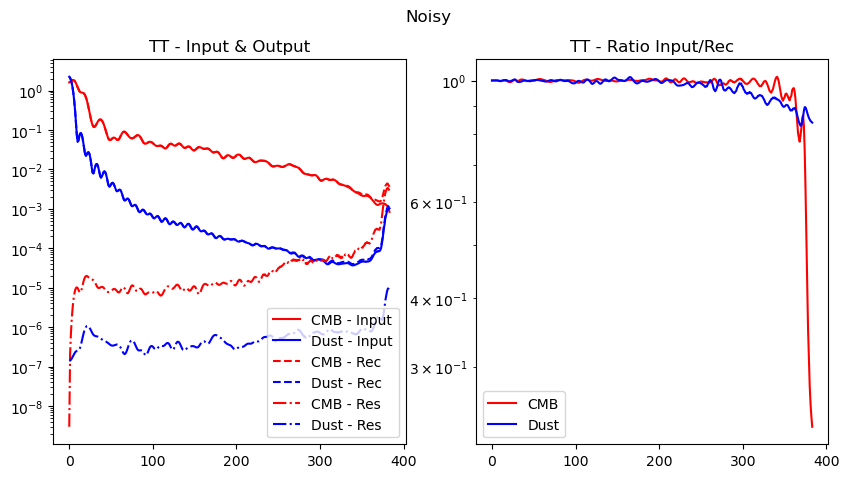

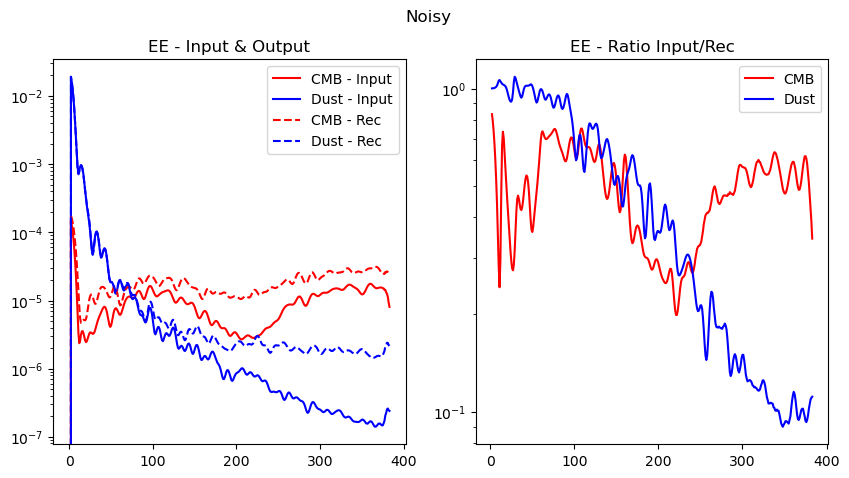

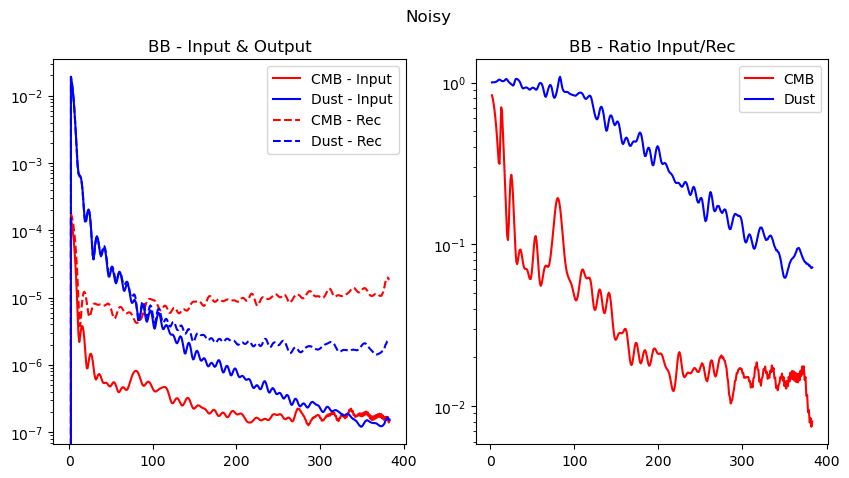

In [7]:
test_input_cmb = hp.anafast(comp_maps_input[0].T)
test_rec_cmb = hp.anafast(comp_maps_rec[0].T)
test_res_cmb = hp.anafast(comp_maps_res[0].T)

test_input_dust = hp.anafast(comp_maps_input[1].T)
test_rec_dust = hp.anafast(comp_maps_rec[1].T)
test_res_dust = hp.anafast(comp_maps_res[1].T)

test_ratio_cmb = test_input_cmb / test_rec_cmb
test_ratio_dust = test_input_dust / test_rec_dust

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle(t="Noisy")
axes[0].set_title("TT - Input & Output")
axes[0].plot(test_input_cmb[0], "r", label="CMB - Input")
axes[0].plot(test_input_dust[0], "b", label="Dust - Input")
axes[0].plot(test_rec_cmb[0], "--r", label="CMB - Rec")
axes[0].plot(test_rec_dust[0], "--b", label="Dust - Rec")
axes[0].plot(test_res_cmb[0], "-.r", label="CMB - Res")
axes[0].plot(test_res_dust[0], "-.b", label="Dust - Res")
axes[0].set_yscale("log")

axes[1].set_title("TT - Ratio Input/Rec")
axes[1].plot(test_ratio_cmb[0], "r", label="CMB")
axes[1].plot(test_ratio_dust[0], "b", label="Dust")
axes[1].set_yscale("log")



axes[0].legend()
axes[1].legend()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle(t="Noisy")
axes[0].set_title("EE - Input & Output")
axes[0].plot(test_input_cmb[1], "r", label="CMB - Input")
axes[0].plot(test_input_dust[1], "b", label="Dust - Input")
axes[0].plot(test_rec_cmb[1], "--r", label="CMB - Rec")
axes[0].plot(test_rec_dust[1], "--b", label="Dust - Rec")
axes[0].set_yscale("log")
axes[1].set_title("EE - Ratio Input/Rec")
axes[1].plot(test_ratio_cmb[1], "r", label="CMB")
axes[1].plot(test_ratio_dust[1], "b", label="Dust")
axes[1].set_yscale("log")
axes[0].legend()
axes[1].legend()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle(t="Noisy")
axes[0].set_title("BB - Input & Output")
axes[0].plot(test_input_cmb[2], "r", label="CMB - Input")
axes[0].plot(test_input_dust[2], "b", label="Dust - Input")
axes[0].plot(test_rec_cmb[2], "--r", label="CMB - Rec")
axes[0].plot(test_rec_dust[2], "--b", label="Dust - Rec")
axes[0].set_yscale("log")
axes[1].set_title("BB - Ratio Input/Rec")
axes[1].plot(test_ratio_cmb[2], "r", label="CMB")
axes[1].plot(test_ratio_dust[2], "b", label="Dust")
axes[1].set_yscale("log")
axes[0].legend()
axes[1].legend()

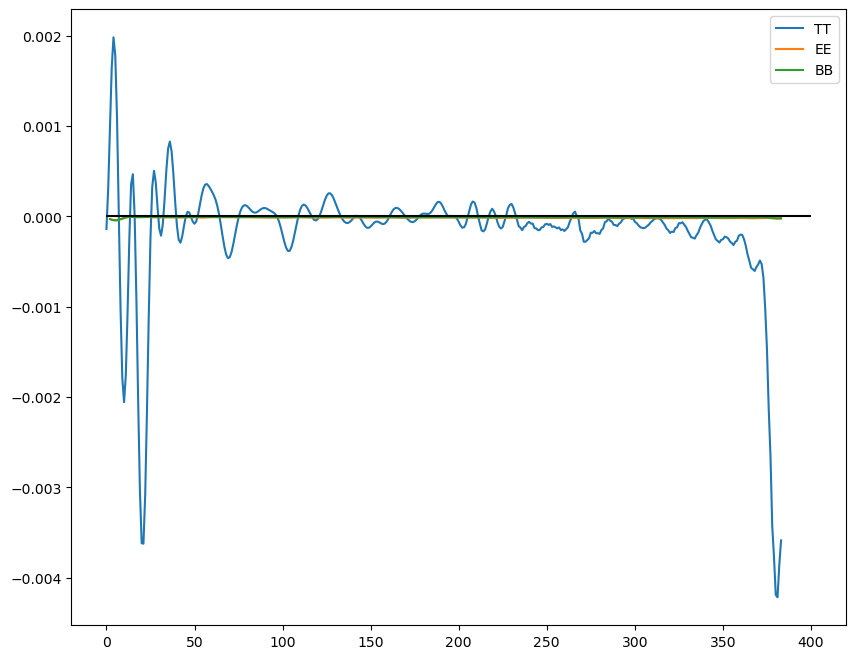

In [8]:
spec = ["TT", "EE","BB" ]
plt.figure(figsize=(10, 8))
test_noise_cmb = np.empty(test_res_cmb.shape)
for idx in range(3):
    test_noise_cmb[idx] = (test_ratio_cmb[idx] - 1) * test_input_cmb[idx]
    plt.plot((test_noise_cmb[idx]- test_res_cmb[idx]), label=spec[idx])
plt.hlines(0, 0, 400, "k")
plt.legend()
# plt.yscale(value="log")
# plt.ylim(-2e-4, 2e-4)

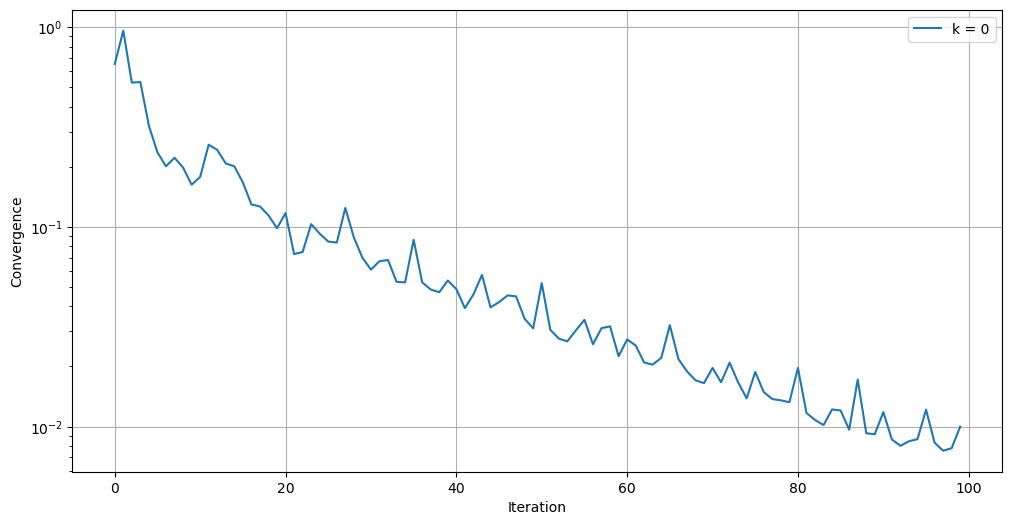

In [9]:
plt.figure(figsize=(12, 6))
for i in range(len(convergence)):
    plt.plot(convergence[i], label=f"k = {i}")

plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.legend()
plt.grid()
plt.yscale("log")
plt.legend()

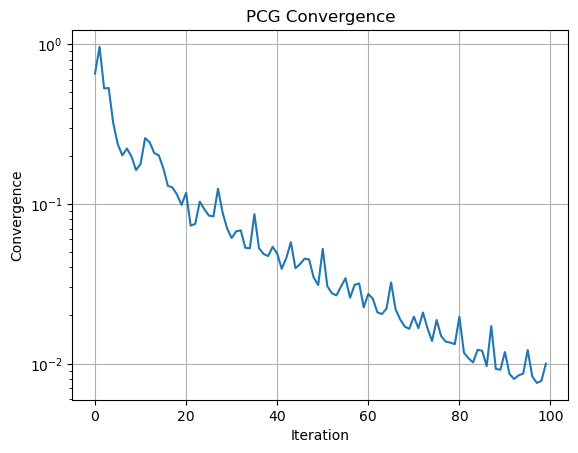

In [10]:
plt.plot(convergence[-1])
plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.title("PCG Convergence")
plt.yscale("log")
plt.grid()
plt.show()

In [11]:
print("FWHM in: ", fwhm_in)
print("mean fwhm in: ", np.mean(fwhm_in))
print("FWHM out: ", fwhm_out)
print("FWHM rec: ", fwhm_rec)

FWHM in:  [0.0075867  0.0071247  0.00669084 0.0062834  0.00517275 0.00485775
 0.00456193 0.00428413 0.00428413 0.00428413]
mean fwhm in:  0.005513046211257119
FWHM out:  [0.00626132 0.00569276 0.00513941 0.00459644 0.00289888 0.00228997
 0.00156763 0.         0.         0.        ]
FWHM rec:  0.0042841330748209575


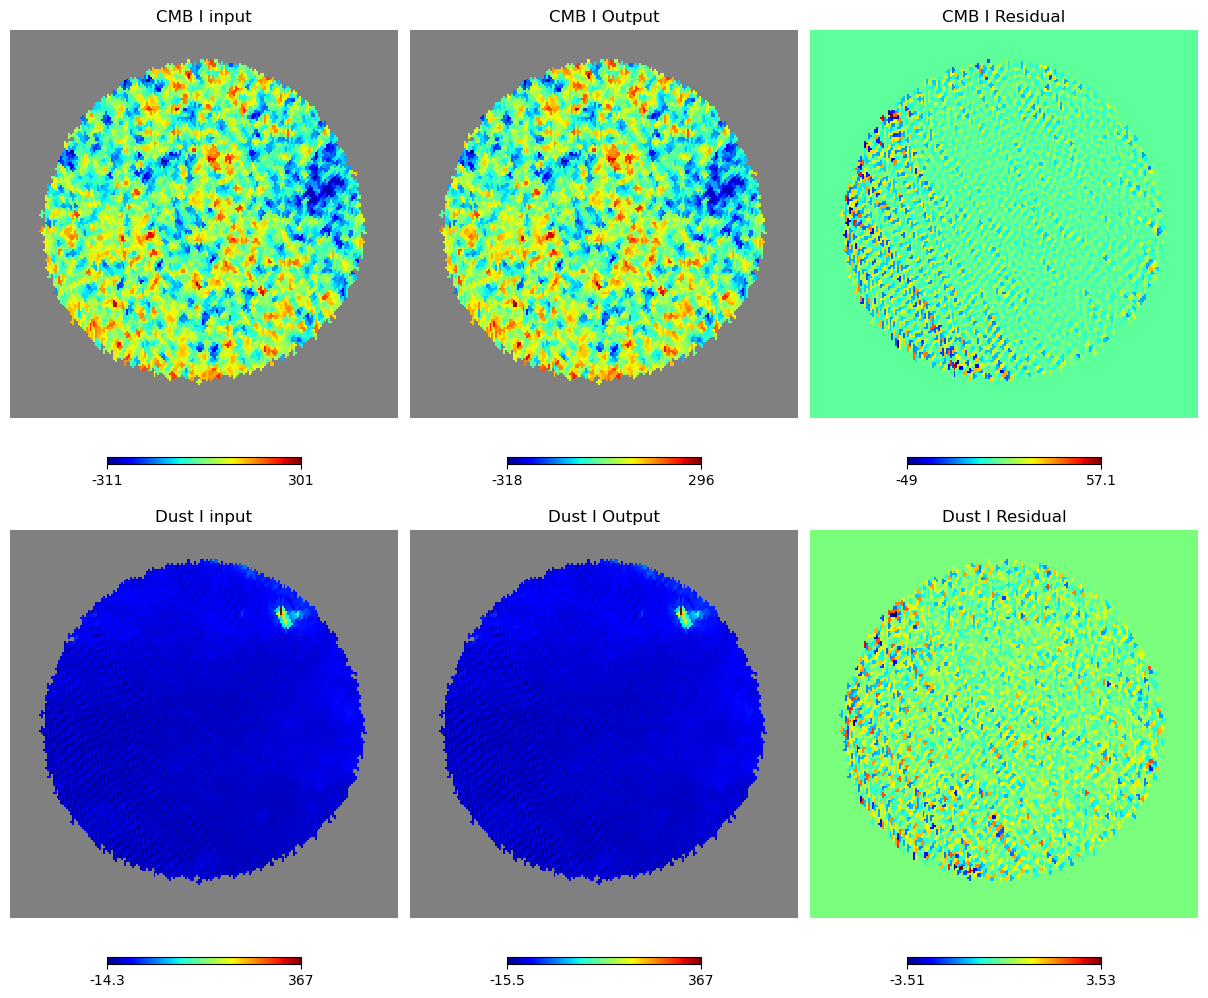

In [12]:
plt.figure(figsize=(12, 10))
name_comp = ["CMB", "Dust", "Synchrotron"]
STOKES = ["I", "Q", "U"]

# comp_maps_input[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_rec[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_res[:, ~seenpix, :] = hp.UNSEEN


istk = 0
n = comp_maps_input.shape[0]
sigma_input = np.std(comp_maps_input[:, seenpix, istk], axis=0)
sigma_rec = np.std(comp_maps_rec[:, seenpix, istk], axis=0)
sigma_res = np.std(comp_maps_rec[:, seenpix, istk] - comp_maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

for icomp in range(n):
    C = HealpixConvolutionGaussianOperator(0)#fwhm_rec[icomp])
    hp.gnomview((C(comp_maps_input[icomp])[ :, istk]), rot=center,

                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
                       
                        sub=(n, 3, k + 1))
    
    hp.gnomview((C(comp_maps_rec[icomp])[ :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
                        # min = - n * sigma_rec[icomp],
                        # max = n * sigma_rec[icomp],
                        sub=(n, 3, k + 2))
    
    hp.gnomview(C(comp_maps_res[icomp])[ :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",  
                        cmap="jet",
               
                        sub=(n, 3, k + 3))
    k += 3

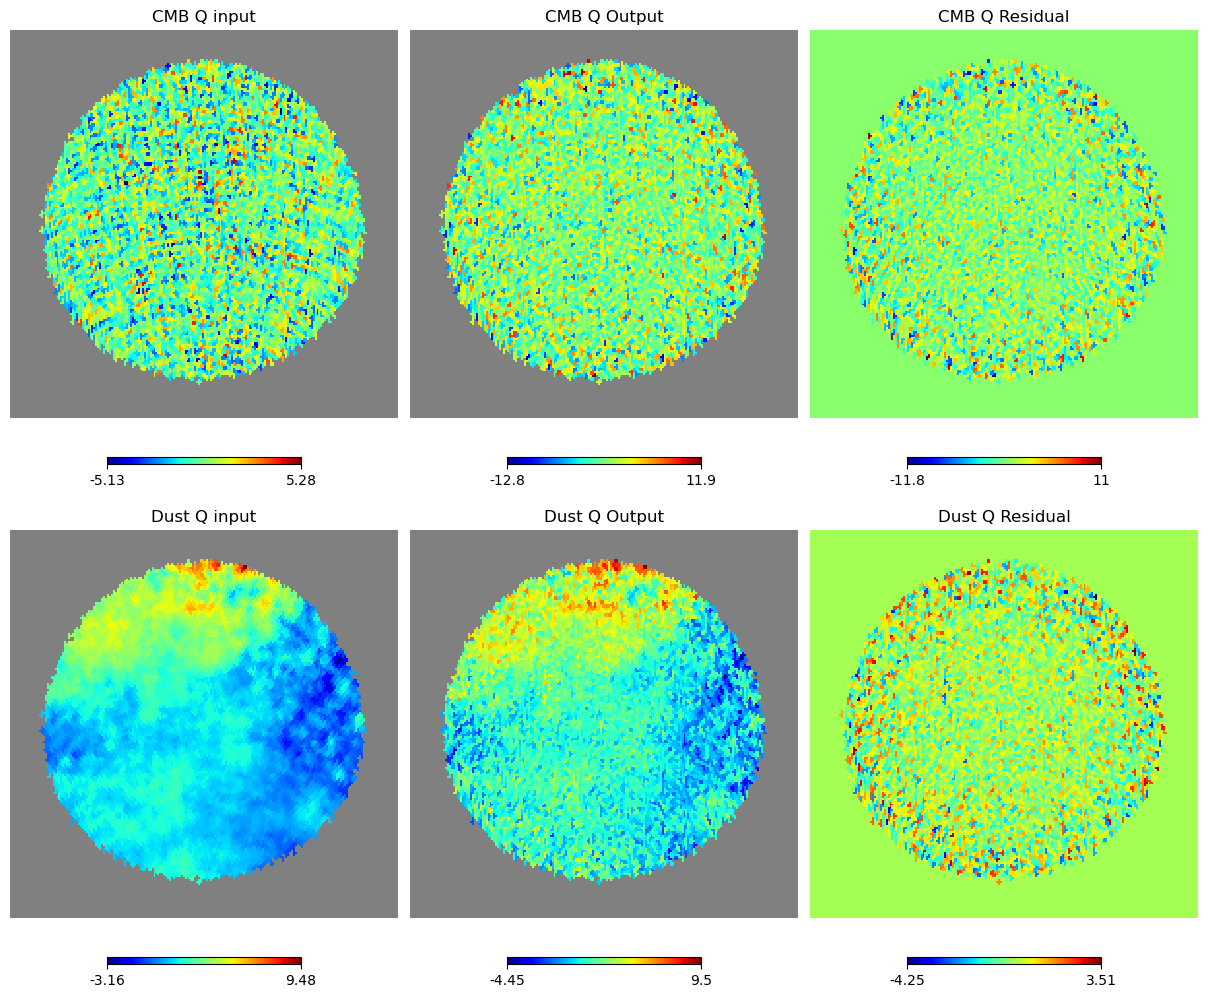

In [13]:
plt.figure(figsize=(12, 10))

# comp_maps_input[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_rec[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_res[:, ~seenpix, :] = hp.UNSEEN

k = 0
istk = 1

for icomp in range(n):
    hp.gnomview((comp_maps_input[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
    
                        sub=(n, 3, k + 1))
    
    hp.gnomview((comp_maps_rec[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
         
                        sub=(n, 3, k + 2))
    
    hp.gnomview(comp_maps_res[icomp, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",
                        cmap="jet",
                   
        # if self.preset_tools.params["PCG"]["fix_pixels_outside_patch"]:
        #     maps_external[:, ~self.preset_sky.seenpix_qubic, :] = 0
        #     self.TOD_external = _r.T(maps_external)

        #     self.seenpix_external = np.tile(self.preset_sky.seenpix_qubic, (maps_external.shape[0], 3, 1)).reshape(maps_external.shape)
                        sub=(n, 3, k + 3))
    k += 3

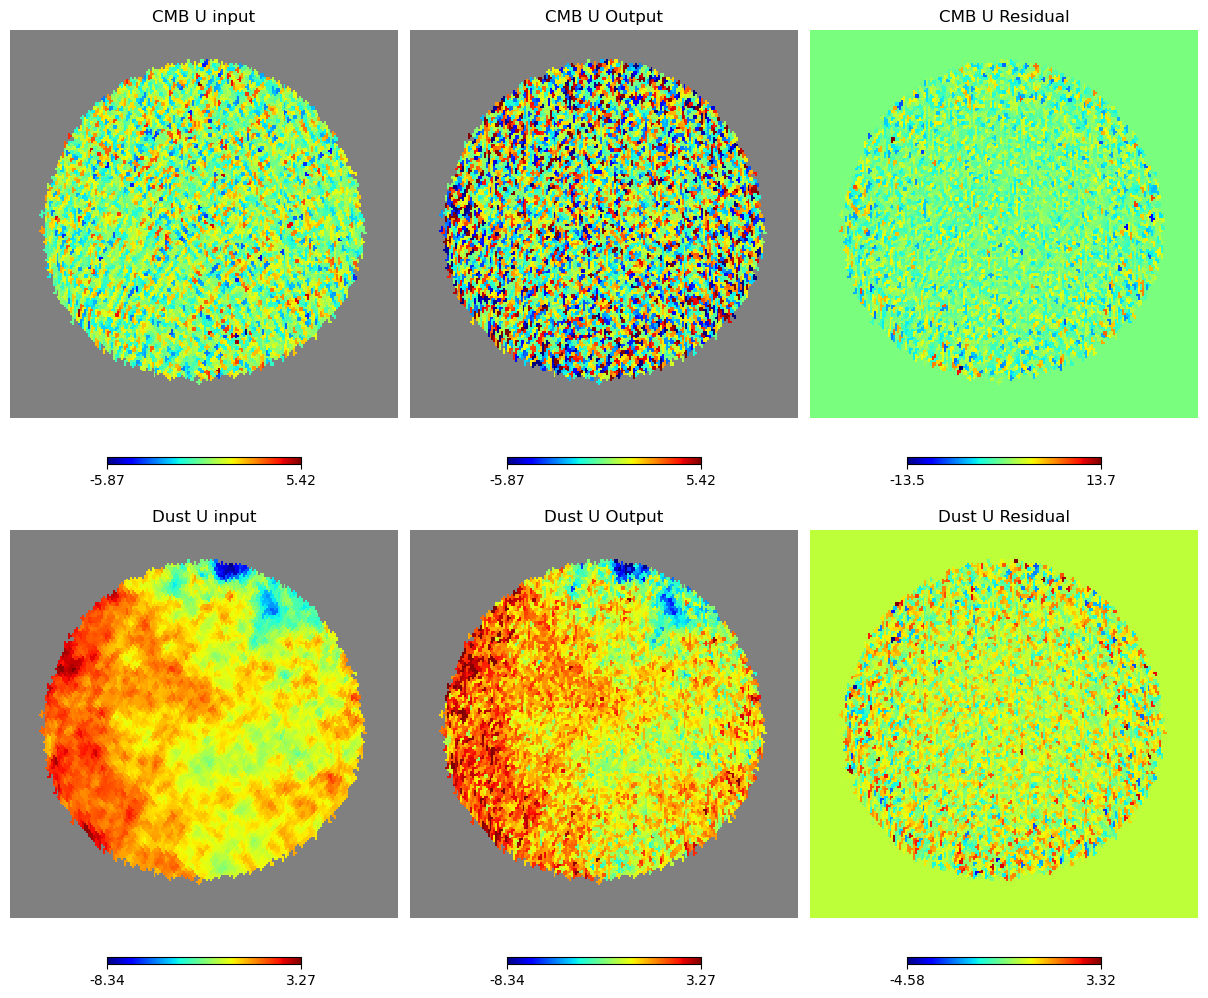

In [14]:
plt.figure(figsize=(12, 10))

min = np.min(comp_maps_input[:, seenpix], axis=1)
max = np.max(comp_maps_input[:, seenpix], axis=1)

k = 0
istk = 2

for icomp in range(n):
    hp.gnomview((comp_maps_input[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
                        min=min[icomp, istk],
                        max=max[icomp, istk],
                        sub=(n, 3, k + 1))
    
    hp.gnomview((comp_maps_rec[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
        # if self.preset_tools.params["PCG"]["fix_pixels_outside_patch"]:
        #     maps_external[:, ~self.preset_sky.seenpix_qubic, :] = 0
        #     self.TOD_external = _r.T(maps_external)

        #     self.seenpix_external = np.tile(self.preset_sky.seenpix_qubic, (maps_external.shape[0], 3, 1)).reshape(maps_external.shape)
                        min=min[icomp, istk],
                        max=max[icomp, istk],
                        sub=(n, 3, k + 2))
    
    hp.gnomview(comp_maps_res[icomp, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",
                        cmap="jet",
                        # min=min[icomp, istk],
                        # max=max[icomp, istk],
                        sub=(n, 3, k + 3))
    k += 3

(194,) (194,) (194,)


(array([ 0.45,  0.65,  0.75,  0.95,  1.05,  1.15,  1.25,  1.35,  1.45,
         1.55,  1.65,  1.75,  1.85,  1.95,  2.05,  2.15,  2.25,  2.35,
         2.45,  2.55,  2.65,  2.75,  2.85,  2.95,  3.05,  3.15,  3.25,
         3.35,  3.45,  3.55,  3.65,  3.75,  3.85,  3.95,  4.05,  4.15,
         4.25,  4.35,  4.45,  4.55,  4.65,  4.75,  4.85,  4.95,  5.05,
         5.15,  5.25,  5.35,  5.45,  5.55,  5.65,  5.75,  5.85,  5.95,
         6.05,  6.15,  6.25,  6.35,  6.45,  6.55,  6.65,  6.75,  6.85,
         6.95,  7.05,  7.15,  7.25,  7.35,  7.45,  7.55,  7.65,  7.75,
         7.85,  7.95,  8.05,  8.15,  8.25,  8.35,  8.45,  8.55,  8.65,
         8.75,  8.85,  8.95,  9.05,  9.15,  9.25,  9.35,  9.45,  9.55,
         9.65,  9.75,  9.85,  9.95, 10.05, 10.15, 10.25, 10.35, 10.45,
        10.55, 10.65, 10.75, 10.85, 10.95, 11.05, 11.15, 11.25, 11.35,
        11.45, 11.55, 11.65, 11.75, 11.85, 11.95, 12.05, 12.15, 12.25,
        12.35, 12.45, 12.55, 12.65, 12.75, 12.85, 12.95, 13.05, 13.15,
      

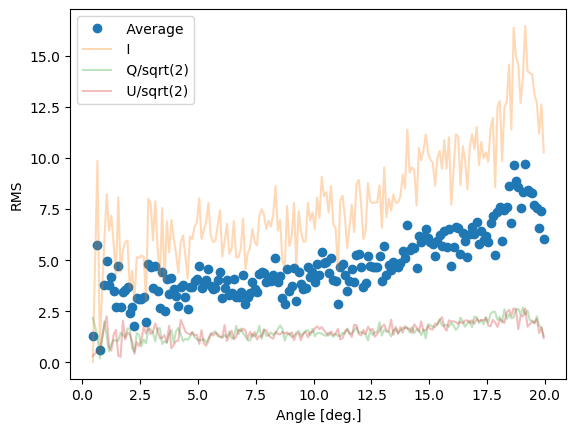

In [15]:
get_angular_profile(comp_maps_res[0], doplot=True, allstokes=True, nbins=200, thmax=20)

In [16]:
stop

NameError: name 'stop' is not defined

In [ ]:
icomp = 0

test_in = data["maps_in"][icomp].copy()
test_out = data["maps"][icomp].copy()

test_in[~seenpix, :] = 0
test_out[~seenpix, :] = 0

In [ ]:
def chi2_fwhm(fwhm):
    C = HealpixConvolutionGaussianOperator(fwhm)
    input_maps = C(test_in)
        
    return np.mean((test_out - input_maps) ** 2)

In [ ]:
list_chi2 = []

fwhm = np.logspace(np.log10(0.0001), np.log10(0.01), num=50)
for i in fwhm:
    list_chi2.append(chi2_fwhm(i))

list_chi2 = np.array(list_chi2)

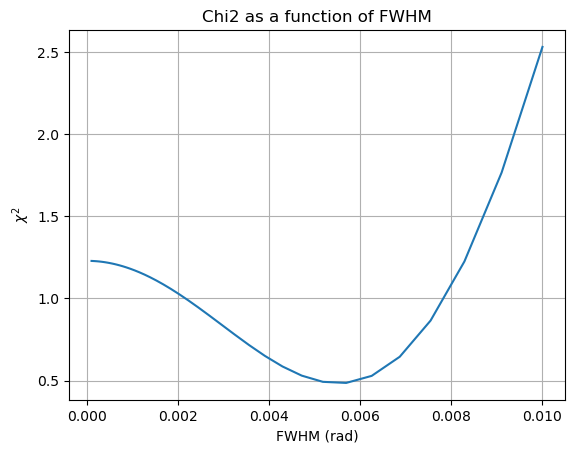

In [ ]:
plt.plot(fwhm, list_chi2)
plt.xlabel("FWHM (rad)")
plt.ylabel(r"$\chi^2$")
plt.title("Chi2 as a function of FWHM")
plt.grid()
plt.show()

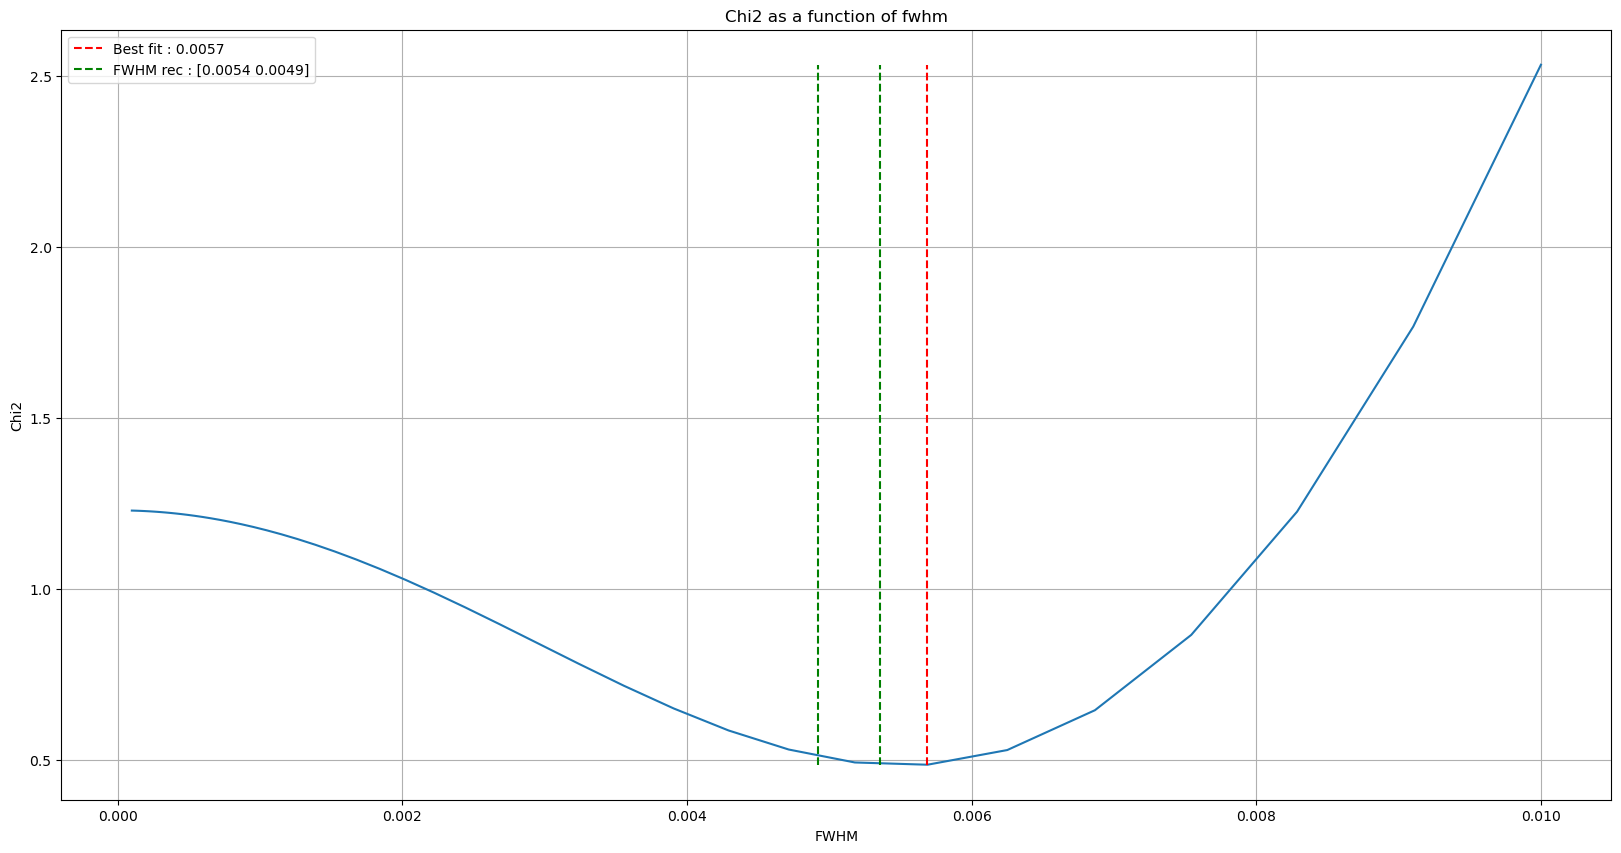

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(fwhm, list_chi2)
plt.vlines(fwhm[np.where(list_chi2 == np.min(list_chi2))[0][0]], np.min(list_chi2), np.max(list_chi2), color="red", linestyle="--", label=f"Best fit : {fwhm[np.where(list_chi2 == np.min(list_chi2))[0][0]].round(4)}")
plt.vlines(fwhm_rec, np.min(list_chi2), np.max(list_chi2), color="green", linestyle="--", label=f"FWHM rec : {fwhm_rec.round(4)}")
plt.title("Chi2 as a function of fwhm")
plt.xlabel("FWHM")
plt.ylabel("Chi2")
plt.grid()
plt.legend()
plt.show()